# GPU-Accelerated Synthetic Classification and Matrix Workloads

This notebook compares NumPy and CuPy on two complementary tasks: synthetic matrix-heavy workloads and a Gaussian-mixture classification problem. Together, they show when GPU acceleration improves throughput, when host-device transfer overhead matters, and how to evaluate a model with both speed and quality metrics.

## What this notebook shows

- Matrix-heavy compute with NumPy and CuPy
- End-to-end versus compute-only GPU timing
- Synthetic classification from Gaussian distributions
- Accuracy, macro precision, macro recall, macro F1, and confusion matrices
- Runtime comparisons across input sizes and batch sizes
- Practical tradeoffs for scientific computing and ML workloads

## Install note

Use `pip install "cupy-cuda13x[ctk]"` for this machine's CUDA 13.2 runtime. The generic `cupy` package may try to build from source when CUDA headers are missing.

In [1]:
import time

import numpy as np
import pandas as pd

try:
    import cupy as cp
except ImportError:
    cp = None


def cpu_matmul(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return a @ b


def gpu_matmul(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    if cp is None:
        raise ImportError('CuPy is not installed.')
    a_gpu = cp.asarray(a)
    b_gpu = cp.asarray(b)
    result_gpu = a_gpu @ b_gpu
    return cp.asnumpy(result_gpu)


def benchmark(fn, *args):
    start = time.perf_counter()
    result = fn(*args)
    elapsed = time.perf_counter() - start
    return result, elapsed

In [2]:
a = np.array([[1, 2], [3, 4]], dtype=np.float32)
b = np.array([[5, 6], [7, 8]], dtype=np.float32)

cpu_result = cpu_matmul(a, b)

sample_inputs_df = pd.DataFrame(
    {
        'A': [a.tolist()],
        'B': [b.tolist()],
        'CPU result': [cpu_result.tolist()],
    },
    index=['2x2 example'],
)

sample_inputs_df

,A,B,CPU result
2x2 example,"[[1.0, 2.0], [3.0, 4.0]]","[[5.0, 6.0], [7.0, 8.0]]","[[19.0, 22.0], [43.0, 50.0]]"


In [3]:
size = 512
a = np.random.default_rng(42).random((size, size), dtype=np.float32)
b = np.random.default_rng(123).random((size, size), dtype=np.float32)

cpu_result_big, cpu_elapsed = benchmark(cpu_matmul, a, b)

benchmark_rows = [
    {
        'backend': 'CPU',
        'size': size,
        'elapsed_seconds': cpu_elapsed,
        'max_abs_diff': 0.0,
    }
]

if cp is None:
    benchmark_rows.append(
        {
            'backend': 'GPU',
            'size': size,
            'elapsed_seconds': np.nan,
            'max_abs_diff': np.nan,
            'note': 'CuPy is not installed',
        }
    )
else:
    gpu_result_big, gpu_elapsed = benchmark(gpu_matmul, a, b)
    max_diff = float(np.max(np.abs(cpu_result_big - gpu_result_big)))
    benchmark_rows.append(
        {
            'backend': 'GPU',
            'size': size,
            'elapsed_seconds': gpu_elapsed,
            'max_abs_diff': max_diff,
        }
    )

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df

,backend,size,elapsed_seconds,max_abs_diff
0,CPU,512,0.060235,0.000000
1,GPU,512,2.287388,0.000107


## Takeaway

Small arrays can still favor NumPy because GPU launch and transfer overhead dominate. Once the workload is large enough, or the data stays resident on the GPU, CuPy becomes the better fit for the compute-heavy parts of the project.

## Synthetic throughput benchmark

This section uses reproducible workloads large enough to expose GPU efficiency when the input is already on device. The point is to separate compute speed from transfer cost so the benchmark tells a realistic performance story.

The next cell builds a size sweep for square matrix multiplication and measures three cases: CPU compute, GPU compute with data already on the device, and GPU end-to-end time including transfers.

In [9]:
sizes = [256, 512, 1024, 2048]
repeats = 8
rng = np.random.default_rng(42)

sweep_rows = []

for size in sizes:
    a_host = rng.random((size, size), dtype=np.float32)
    b_host = rng.random((size, size), dtype=np.float32)

    _ = a_host @ b_host
    start = time.perf_counter()
    for _ in range(repeats):
        cpu_result = a_host @ b_host
    cpu_seconds = (time.perf_counter() - start) / repeats

    if cp is not None:
        a_gpu = cp.asarray(a_host)
        b_gpu = cp.asarray(b_host)
        _ = a_gpu @ b_gpu
        cp.cuda.Stream.null.synchronize()

        start = time.perf_counter()
        for _ in range(repeats):
            gpu_resident = a_gpu @ b_gpu
        cp.cuda.Stream.null.synchronize()
        gpu_compute_seconds = (time.perf_counter() - start) / repeats

        start = time.perf_counter()
        for _ in range(repeats):
            gpu_end_to_end = cp.asnumpy(cp.asarray(a_host) @ cp.asarray(b_host))
        cp.cuda.Stream.null.synchronize()
        gpu_end_to_end_seconds = (time.perf_counter() - start) / repeats

        speedup = cpu_seconds / gpu_compute_seconds
        max_diff = float(np.max(np.abs(cpu_result - cp.asnumpy(gpu_resident))))

        sweep_rows.extend(
            [
                {
                    'size': size,
                    'backend': 'NumPy',
                    'mode': 'compute only',
                    'avg_ms': cpu_seconds * 1000,
                    'speedup_vs_cpu': 1.0,
                    'max_abs_diff': 0.0,
                },
                {
                    'size': size,
                    'backend': 'CuPy',
                    'mode': 'compute only',
                    'avg_ms': gpu_compute_seconds * 1000,
                    'speedup_vs_cpu': speedup,
                    'max_abs_diff': max_diff,
                },
                {
                    'size': size,
                    'backend': 'CuPy',
                    'mode': 'end to end',
                    'avg_ms': gpu_end_to_end_seconds * 1000,
                    'speedup_vs_cpu': cpu_seconds / gpu_end_to_end_seconds,
                    'max_abs_diff': max_diff,
                },
            ]
        )
    else:
        sweep_rows.append(
            {
                'size': size,
                'backend': 'NumPy',
                'mode': 'compute only',
                'avg_ms': cpu_seconds * 1000,
                'speedup_vs_cpu': 1.0,
                'max_abs_diff': 0.0,
            }
        )

matrix_sweep_df = pd.DataFrame(sweep_rows)
matrix_sweep_df

,size,backend,mode,avg_ms,speedup_vs_cpu,max_abs_diff
0,256,NumPy,compute only,22.173066,1.000000,0.000000
1,256,CuPy,compute only,0.203180,109.129892,0.000061
2,256,CuPy,end to end,1.718758,12.900631,0.000061
3,512,NumPy,compute only,14.251049,1.000000,0.000000
4,512,CuPy,compute only,1.169777,12.182703,0.000107
5,512,CuPy,end to end,7.572227,1.882016,0.000107
6,1024,NumPy,compute only,7.889072,1.000000,0.000000
7,1024,CuPy,compute only,5.514766,1.430536,0.000336
8,1024,CuPy,end to end,14.208199,0.555248,0.000336
9,2048,NumPy,compute only,58.761083,1.000000,0.000000


This next cell benchmarks a synthetic linear layer, which is closer to an ML inference kernel and usually benefits from GPU acceleration once the batch and feature dimensions are large enough.

In [12]:
def benchmark_linear_layer(batch_sizes, features=4096, outputs=1024, repeats=6):
    rng = np.random.default_rng(7)
    weight_host = rng.random((features, outputs), dtype=np.float32)
    bias_host = rng.random((outputs,), dtype=np.float32)
    rows = []

    if cp is not None:
        weight_gpu = cp.asarray(weight_host)
        bias_gpu = cp.asarray(bias_host)

    for batch_size in batch_sizes:
        x_host = rng.random((batch_size, features), dtype=np.float32)

        _ = x_host @ weight_host + bias_host
        start = time.perf_counter()
        for _ in range(repeats):
            cpu_output = x_host @ weight_host + bias_host
        cpu_seconds = (time.perf_counter() - start) / repeats

        if cp is not None:
            x_gpu = cp.asarray(x_host)
            _ = x_gpu @ weight_gpu + bias_gpu
            cp.cuda.Stream.null.synchronize()

            start = time.perf_counter()
            for _ in range(repeats):
                gpu_output = x_gpu @ weight_gpu + bias_gpu
            cp.cuda.Stream.null.synchronize()
            gpu_seconds = (time.perf_counter() - start) / repeats

            start = time.perf_counter()
            for _ in range(repeats):
                _ = cp.asnumpy(cp.asarray(x_host) @ weight_gpu + bias_gpu)
            cp.cuda.Stream.null.synchronize()
            gpu_end_seconds = (time.perf_counter() - start) / repeats

            max_diff = float(np.max(np.abs(cpu_output - cp.asnumpy(gpu_output))))

            rows.extend(
                [
                    {
                        'workload': 'linear layer',
                        'batch_size': batch_size,
                        'backend': 'NumPy',
                        'mode': 'compute only',
                        'avg_ms': cpu_seconds * 1000,
                        'speedup_vs_cpu': 1.0,
                        'max_abs_diff': 0.0,
                    },
                    {
                        'workload': 'linear layer',
                        'batch_size': batch_size,
                        'backend': 'CuPy',
                        'mode': 'compute only',
                        'avg_ms': gpu_seconds * 1000,
                        'speedup_vs_cpu': cpu_seconds / gpu_seconds,
                        'max_abs_diff': max_diff,
                    },
                    {
                        'workload': 'linear layer',
                        'batch_size': batch_size,
                        'backend': 'CuPy',
                        'mode': 'end to end',
                        'avg_ms': gpu_end_seconds * 1000,
                        'speedup_vs_cpu': cpu_seconds / gpu_end_seconds,
                        'max_abs_diff': max_diff,
                    },
                ]
            )
        else:
            rows.append(
                {
                    'workload': 'linear layer',
                    'batch_size': batch_size,
                    'backend': 'NumPy',
                    'mode': 'compute only',
                    'avg_ms': cpu_seconds * 1000,
                    'speedup_vs_cpu': 1.0,
                    'max_abs_diff': 0.0,
                }
            )

    return pd.DataFrame(rows)


batch_sizes = [32, 128, 512, 2048]
linear_layer_df = benchmark_linear_layer(batch_sizes)
linear_layer_df

,workload,batch_size,backend,mode,avg_ms,speedup_vs_cpu,max_abs_diff
0,linear layer,32,NumPy,compute only,50.172770,1.000000,0.000000
1,linear layer,32,CuPy,compute only,3.264501,15.369198,0.000488
2,linear layer,32,CuPy,end to end,4.118750,12.181553,0.000488
3,linear layer,128,NumPy,compute only,19.788212,1.000000,0.000000
4,linear layer,128,CuPy,compute only,5.637561,3.510066,0.001953
5,linear layer,128,CuPy,end to end,8.106867,2.440920,0.001953
6,linear layer,512,NumPy,compute only,10.493444,1.000000,0.000000
7,linear layer,512,CuPy,compute only,6.644907,1.579171,0.002319
8,linear layer,512,CuPy,end to end,15.427224,0.680190,0.002319
9,linear layer,2048,NumPy,compute only,57.596911,1.000000,0.000000


The next cell benchmarks batched matrix multiplication, which is another synthetic workload that can show GPU efficiency when the batch dimension gets large.

In [14]:
def benchmark_batched_gemm(batch_sizes, matrix_size=256, repeats=6):
    rng = np.random.default_rng(99)
    weight_host = rng.random((matrix_size, matrix_size), dtype=np.float32)
    rows = []

    if cp is not None:
        weight_gpu = cp.asarray(weight_host)

    for batch_size in batch_sizes:
        x_host = rng.random((batch_size, matrix_size, matrix_size), dtype=np.float32)

        _ = x_host @ weight_host
        start = time.perf_counter()
        for _ in range(repeats):
            cpu_output = x_host @ weight_host
        cpu_seconds = (time.perf_counter() - start) / repeats

        if cp is not None:
            x_gpu = cp.asarray(x_host)
            _ = x_gpu @ weight_gpu
            cp.cuda.Stream.null.synchronize()

            start = time.perf_counter()
            for _ in range(repeats):
                gpu_output = x_gpu @ weight_gpu
            cp.cuda.Stream.null.synchronize()
            gpu_seconds = (time.perf_counter() - start) / repeats

            start = time.perf_counter()
            for _ in range(repeats):
                _ = cp.asnumpy(cp.asarray(x_host) @ weight_gpu)
            cp.cuda.Stream.null.synchronize()
            gpu_end_seconds = (time.perf_counter() - start) / repeats

            max_diff = float(np.max(np.abs(cpu_output - cp.asnumpy(gpu_output))))

            rows.extend(
                [
                    {
                        'workload': 'batched gemm',
                        'batch_size': batch_size,
                        'backend': 'NumPy',
                        'mode': 'compute only',
                        'avg_ms': cpu_seconds * 1000,
                        'speedup_vs_cpu': 1.0,
                        'max_abs_diff': 0.0,
                    },
                    {
                        'workload': 'batched gemm',
                        'batch_size': batch_size,
                        'backend': 'CuPy',
                        'mode': 'compute only',
                        'avg_ms': gpu_seconds * 1000,
                        'speedup_vs_cpu': cpu_seconds / gpu_seconds,
                        'max_abs_diff': max_diff,
                    },
                    {
                        'workload': 'batched gemm',
                        'batch_size': batch_size,
                        'backend': 'CuPy',
                        'mode': 'end to end',
                        'avg_ms': gpu_end_seconds * 1000,
                        'speedup_vs_cpu': cpu_seconds / gpu_end_seconds,
                        'max_abs_diff': max_diff,
                    },
                ]
            )
        else:
            rows.append(
                {
                    'workload': 'batched gemm',
                    'batch_size': batch_size,
                    'backend': 'NumPy',
                    'mode': 'compute only',
                    'avg_ms': cpu_seconds * 1000,
                    'speedup_vs_cpu': 1.0,
                    'max_abs_diff': 0.0,
                }
            )

    return pd.DataFrame(rows)


batch_sizes = [8, 32, 128, 512]
batched_gemm_df = benchmark_batched_gemm(batch_sizes)
batched_gemm_df

,workload,batch_size,backend,mode,avg_ms,speedup_vs_cpu,max_abs_diff
0,batched gemm,8,NumPy,compute only,18.844672,1.000000,0.000000
1,batched gemm,8,CuPy,compute only,0.916578,20.559816,0.000084
2,batched gemm,8,CuPy,end to end,4.394185,4.288548,0.000084
3,batched gemm,32,NumPy,compute only,7.258816,1.000000,0.000000
4,batched gemm,32,CuPy,compute only,3.716120,1.953332,0.000092
5,batched gemm,32,CuPy,end to end,15.430057,0.470434,0.000092
6,batched gemm,128,NumPy,compute only,132.062752,1.000000,0.000000
7,batched gemm,128,CuPy,compute only,14.348771,9.203767,0.000107
8,batched gemm,128,CuPy,end to end,67.237738,1.964117,0.000107
9,batched gemm,512,NumPy,compute only,539.999589,1.000000,0.000000


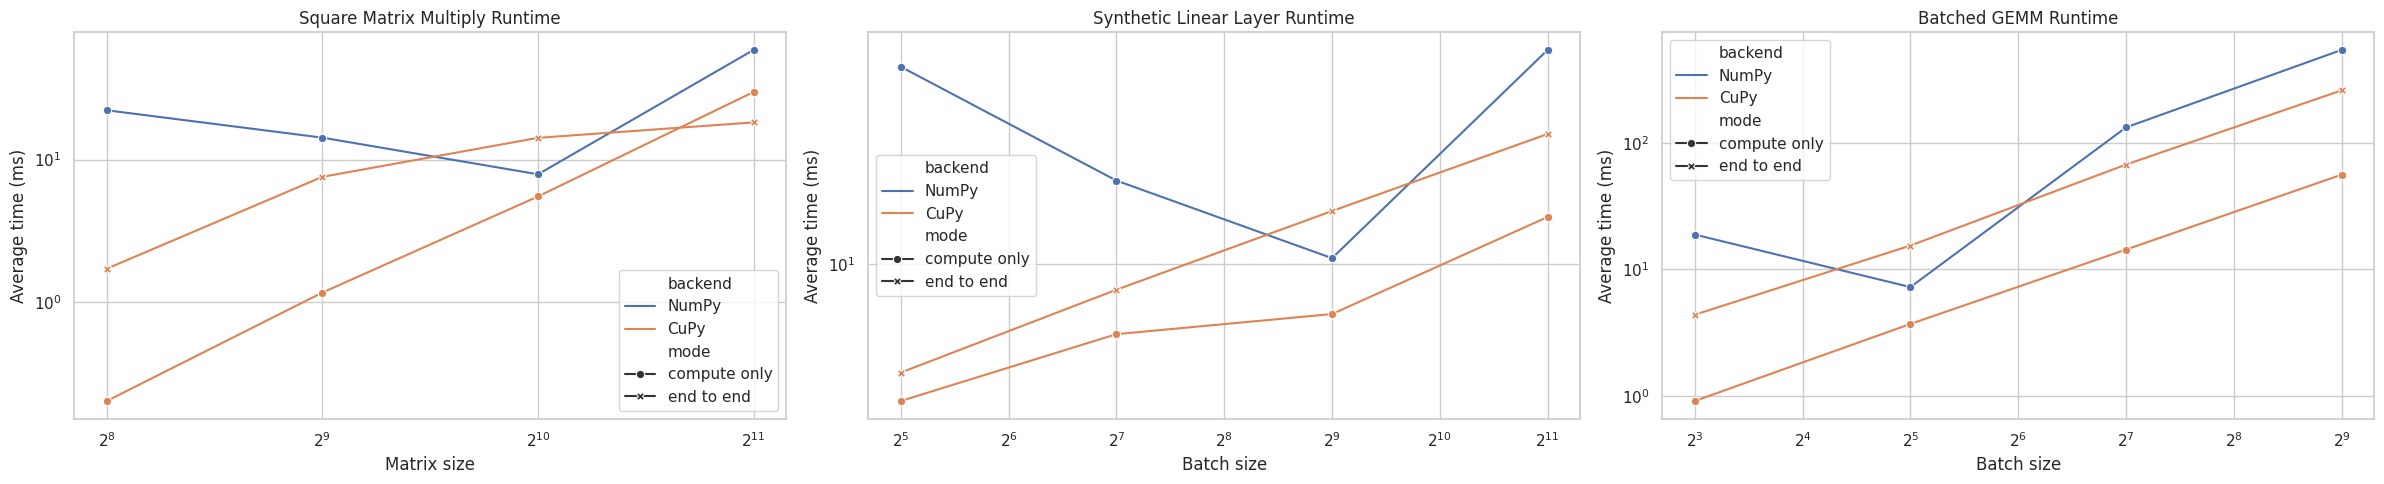

,size,backend,avg_ms,speedup_vs_cpu,workload
0,256,NumPy,22.173066,1.000000,matrix multiply
1,256,CuPy,0.203180,109.129892,matrix multiply
2,512,NumPy,14.251049,1.000000,matrix multiply
3,512,CuPy,1.169777,12.182703,matrix multiply
4,1024,NumPy,7.889072,1.000000,matrix multiply
5,1024,CuPy,5.514766,1.430536,matrix multiply
6,2048,NumPy,58.761083,1.000000,matrix multiply
7,2048,CuPy,29.803076,1.971645,matrix multiply
8,32,NumPy,50.172770,1.000000,linear layer
9,32,CuPy,3.264501,15.369198,linear layer


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(24, 5))

sns.lineplot(
    data=matrix_sweep_df,
    x='size',
    y='avg_ms',
    hue='backend',
    style='mode',
    markers=True,
    dashes=False,
    ax=axes[0],
)
axes[0].set_title('Square Matrix Multiply Runtime')
axes[0].set_xlabel('Matrix size')
axes[0].set_ylabel('Average time (ms)')
axes[0].set_xscale('log', base=2)
axes[0].set_yscale('log')

sns.lineplot(
    data=linear_layer_df,
    x='batch_size',
    y='avg_ms',
    hue='backend',
    style='mode',
    markers=True,
    dashes=False,
    ax=axes[1],
)
axes[1].set_title('Synthetic Linear Layer Runtime')
axes[1].set_xlabel('Batch size')
axes[1].set_ylabel('Average time (ms)')
axes[1].set_xscale('log', base=2)
axes[1].set_yscale('log')

sns.lineplot(
    data=batched_gemm_df,
    x='batch_size',
    y='avg_ms',
    hue='backend',
    style='mode',
    markers=True,
    dashes=False,
    ax=axes[2],
)
axes[2].set_title('Batched GEMM Runtime')
axes[2].set_xlabel('Batch size')
axes[2].set_ylabel('Average time (ms)')
axes[2].set_xscale('log', base=2)
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

benchmark_summary_df = pd.concat(
    [
        matrix_sweep_df.loc[matrix_sweep_df['mode'] == 'compute only', ['size', 'backend', 'avg_ms', 'speedup_vs_cpu']].assign(workload='matrix multiply'),
        linear_layer_df.loc[linear_layer_df['mode'] == 'compute only', ['batch_size', 'backend', 'avg_ms', 'speedup_vs_cpu']].rename(columns={'batch_size': 'size'}).assign(workload='linear layer'),
        batched_gemm_df.loc[batched_gemm_df['mode'] == 'compute only', ['batch_size', 'backend', 'avg_ms', 'speedup_vs_cpu']].rename(columns={'batch_size': 'size'}).assign(workload='batched gemm'),
    ],
    ignore_index=True,
)
benchmark_summary_df

## Synthetic classification benchmark

This section samples a three-class Gaussian mixture in 64 dimensions, trains a softmax regression classifier, and reports both performance and model-quality metrics for NumPy and CuPy. 

The next cell generates the synthetic classes and shows a compact summary of the class balance and feature dimensions.

In [16]:
def make_gaussian_mixture_dataset(n_per_class=20000, dim=64, seed=2026):
    rng = np.random.default_rng(seed)
    num_classes = 3
    means = np.zeros((num_classes, dim), dtype=np.float32)
    means[0, 0] = 4.0
    means[1, 1] = 4.0
    means[2, 0] = -4.0
    means[2, 1] = -4.0
    covariance = np.eye(dim, dtype=np.float32) * 1.8

    feature_blocks = []
    label_blocks = []
    for class_index in range(num_classes):
        class_samples = rng.multivariate_normal(means[class_index], covariance, size=n_per_class).astype(np.float32)
        feature_blocks.append(class_samples)
        label_blocks.append(np.full(n_per_class, class_index, dtype=np.int64))

    features = np.vstack(feature_blocks)
    labels = np.concatenate(label_blocks)
    permutation = rng.permutation(features.shape[0])
    features = features[permutation]
    labels = labels[permutation]

    split_index = int(0.8 * features.shape[0])
    X_train = features[:split_index]
    X_test = features[split_index:]
    y_train = labels[:split_index]
    y_test = labels[split_index:]

    feature_mean = X_train.mean(axis=0)
    feature_std = X_train.std(axis=0) + 1e-6
    X_train = (X_train - feature_mean) / feature_std
    X_test = (X_test - feature_mean) / feature_std

    return X_train.astype(np.float32), X_test.astype(np.float32), y_train, y_test, means


X_train_cls, X_test_cls, y_train_cls, y_test_cls, class_means = make_gaussian_mixture_dataset()
class_summary_df = pd.DataFrame(
    [
        {
            'split': 'train',
            'samples': X_train_cls.shape[0],
            'features': X_train_cls.shape[1],
            'classes': len(np.unique(y_train_cls)),
        },
        {
            'split': 'test',
            'samples': X_test_cls.shape[0],
            'features': X_test_cls.shape[1],
            'classes': len(np.unique(y_test_cls)),
        },
    ]
)
class_summary_df

,split,samples,features,classes
0,train,48000,64,3
1,test,12000,64,3


The next cell defines a backend-agnostic softmax regression trainer and computes summary metrics for both CPU and GPU backends.

In [17]:
def _softmax_backend(backend, logits):
    shifted = logits - backend.max(logits, axis=1, keepdims=True)
    exp_logits = backend.exp(shifted)
    return exp_logits / backend.sum(exp_logits, axis=1, keepdims=True)


def _one_hot_backend(backend, labels, num_classes):
    if backend is np:
        return np.eye(num_classes, dtype=np.float32)[labels]
    return backend.eye(num_classes, dtype=backend.float32)[labels]


def _synchronize(backend):
    if backend is cp:
        backend.cuda.Stream.null.synchronize()


def _classification_metrics_from_confusion(confusion_matrix):
    true_positive = np.diag(confusion_matrix).astype(np.float32)
    support = confusion_matrix.sum(axis=1).astype(np.float32)
    predicted = confusion_matrix.sum(axis=0).astype(np.float32)

    precision = np.divide(true_positive, predicted, out=np.zeros_like(true_positive), where=predicted != 0)
    recall = np.divide(true_positive, support, out=np.zeros_like(true_positive), where=support != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(true_positive), where=(precision + recall) != 0)
    accuracy = float(true_positive.sum() / confusion_matrix.sum())

    return {
        'accuracy': accuracy,
        'macro_precision': float(precision.mean()),
        'macro_recall': float(recall.mean()),
        'macro_f1': float(f1.mean()),
    }


def train_softmax_classifier(backend, X_train, y_train, X_test, y_test, *, epochs=16, batch_size=2048, learning_rate=0.4):
    X_train_backend = backend.asarray(X_train, dtype=backend.float32)
    X_test_backend = backend.asarray(X_test, dtype=backend.float32)
    y_train_backend = backend.asarray(y_train)
    y_test_backend = backend.asarray(y_test)

    num_samples, num_features = X_train_backend.shape
    num_classes = int(backend.max(y_train_backend)) + 1
    weights = backend.zeros((num_features, num_classes), dtype=backend.float32)
    bias = backend.zeros((num_classes,), dtype=backend.float32)
    y_train_one_hot = _one_hot_backend(backend, y_train_backend, num_classes)

    history_rows = []
    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        permutation = backend.random.permutation(num_samples)
        for start_index in range(0, num_samples, batch_size):
            batch_indices = permutation[start_index:start_index + batch_size]
            X_batch = X_train_backend[batch_indices]
            y_batch = y_train_one_hot[batch_indices]

            logits = X_batch @ weights + bias
            probabilities = _softmax_backend(backend, logits)
            batch_length = X_batch.shape[0]

            gradient_w = (X_batch.T @ (probabilities - y_batch)) / batch_length
            gradient_b = backend.mean(probabilities - y_batch, axis=0)

            weights = weights - learning_rate * gradient_w
            bias = bias - learning_rate * gradient_b

        train_logits = X_train_backend @ weights + bias
        test_logits = X_test_backend @ weights + bias
        train_loss = -backend.mean(backend.sum(y_train_one_hot * backend.log(_softmax_backend(backend, train_logits) + 1e-10), axis=1))
        train_accuracy = backend.mean(backend.argmax(train_logits, axis=1) == y_train_backend)
        test_accuracy = backend.mean(backend.argmax(test_logits, axis=1) == y_test_backend)
        _synchronize(backend)

        history_rows.append(
            {
                'backend': 'CuPy' if backend is cp else 'NumPy',
                'epoch': epoch,
                'train_loss': float(train_loss),
                'train_accuracy': float(train_accuracy),
                'test_accuracy': float(test_accuracy),
            }
        )

    _synchronize(backend)
    elapsed_seconds = time.perf_counter() - start_time

    if backend is cp:
        train_predictions = cp.asnumpy(backend.argmax(train_logits, axis=1))
        test_predictions = cp.asnumpy(backend.argmax(test_logits, axis=1))
    else:
        train_predictions = backend.argmax(train_logits, axis=1)
        test_predictions = backend.argmax(test_logits, axis=1)

    train_confusion = np.zeros((num_classes, num_classes), dtype=np.int64)
    test_confusion = np.zeros((num_classes, num_classes), dtype=np.int64)
    for true_label, predicted_label in zip(np.asarray(y_train), np.asarray(train_predictions)):
        train_confusion[true_label, predicted_label] += 1
    for true_label, predicted_label in zip(np.asarray(y_test), np.asarray(test_predictions)):
        test_confusion[true_label, predicted_label] += 1

    metrics = _classification_metrics_from_confusion(test_confusion)
    metrics.update(
        {
            'backend': 'CuPy' if backend is cp else 'NumPy',
            'train_accuracy': float(np.mean(np.asarray(train_predictions) == np.asarray(y_train))),
            'elapsed_seconds': elapsed_seconds,
        }
    )

    return (
        pd.DataFrame(history_rows),
        pd.DataFrame([metrics]),
        pd.DataFrame(train_confusion, index=[f'true_{i}' for i in range(num_classes)], columns=[f'pred_{i}' for i in range(num_classes)]),
        pd.DataFrame(test_confusion, index=[f'true_{i}' for i in range(num_classes)], columns=[f'pred_{i}' for i in range(num_classes)]),
    )


cpu_history_cls_df, cpu_metrics_df, cpu_train_confusion_df, cpu_test_confusion_df = train_softmax_classifier(np, X_train_cls, y_train_cls, X_test_cls, y_test_cls)
if cp is not None:
    gpu_history_cls_df, gpu_metrics_df, gpu_train_confusion_df, gpu_test_confusion_df = train_softmax_classifier(cp, X_train_cls, y_train_cls, X_test_cls, y_test_cls)
    classification_metrics_df = pd.concat([cpu_metrics_df, gpu_metrics_df], ignore_index=True)
else:
    gpu_history_cls_df = pd.DataFrame()
    gpu_metrics_df = pd.DataFrame()
    gpu_train_confusion_df = pd.DataFrame()
    gpu_test_confusion_df = pd.DataFrame()
    classification_metrics_df = cpu_metrics_df.copy()

classification_metrics_df

,accuracy,macro_precision,macro_recall,macro_f1,backend,train_accuracy,elapsed_seconds
0,0.986167,0.986304,0.986321,0.986312,NumPy,0.987938,1.217581
1,0.986333,0.986460,0.986495,0.986477,CuPy,0.988042,0.755018


The next cell visualizes the sampled classes, training curves, and the confusion matrix so the classification story is easy to read.

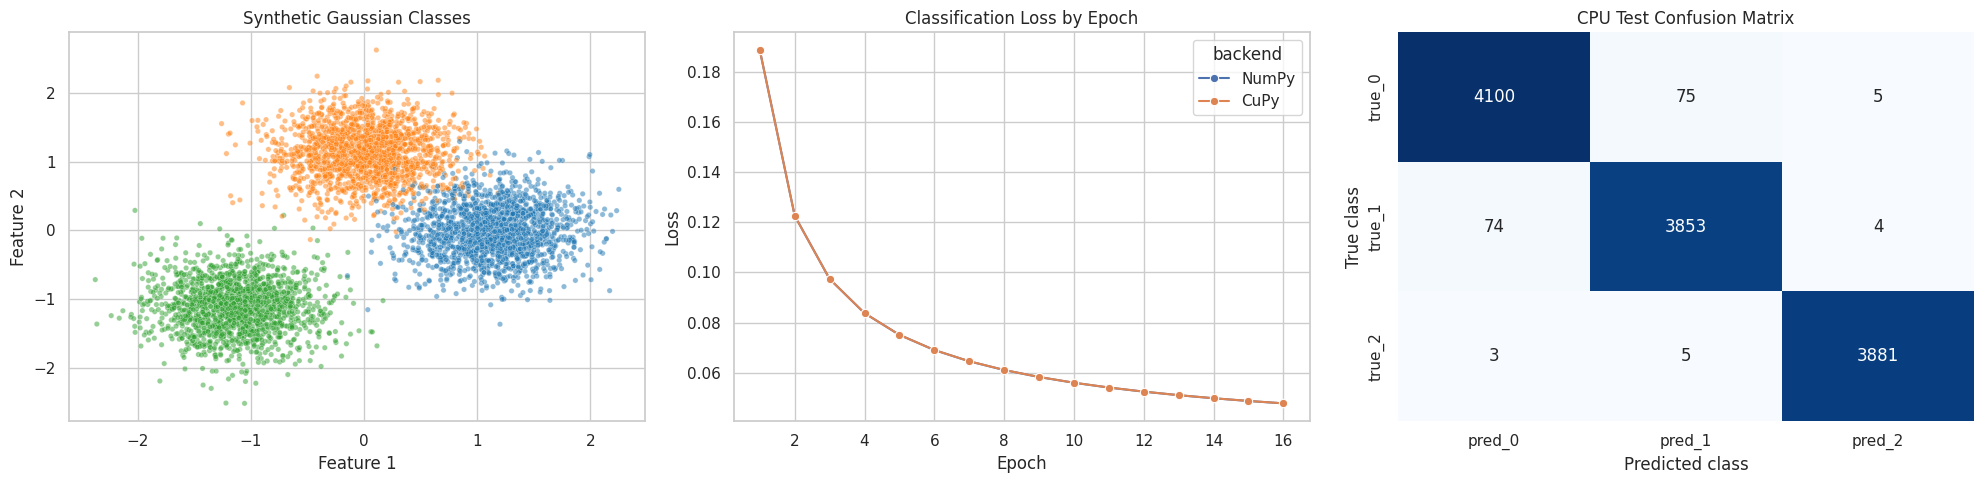

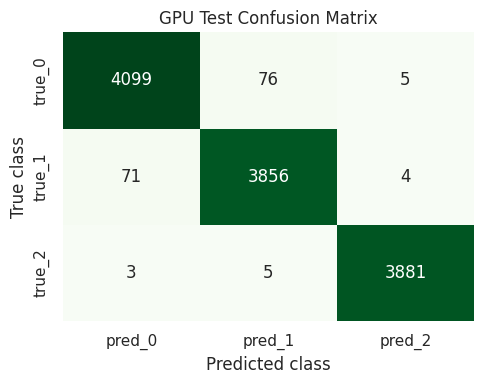

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

sample_count = min(5000, len(X_test_cls))
plot_indices = np.random.default_rng(11).choice(len(X_test_cls), size=sample_count, replace=False)
plot_frame = pd.DataFrame(
    {
        'feature_1': X_test_cls[plot_indices, 0],
        'feature_2': X_test_cls[plot_indices, 1],
        'label': y_test_cls[plot_indices],
    }
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.scatterplot(data=plot_frame, x='feature_1', y='feature_2', hue='label', palette='tab10', s=15, alpha=0.5, ax=axes[0], legend=False)
axes[0].set_title('Synthetic Gaussian Classes')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

history_plot_df = pd.concat(
    [
        cpu_history_cls_df[['epoch', 'train_loss', 'test_accuracy']].assign(backend='NumPy'),
        gpu_history_cls_df[['epoch', 'train_loss', 'test_accuracy']].assign(backend='CuPy') if not gpu_history_cls_df.empty else pd.DataFrame(columns=['epoch', 'train_loss', 'test_accuracy', 'backend']),
    ],
    ignore_index=True,
)

sns.lineplot(data=history_plot_df, x='epoch', y='train_loss', hue='backend', marker='o', ax=axes[1])
axes[1].set_title('Classification Loss by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

sns.heatmap(cpu_test_confusion_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2])
axes[2].set_title('CPU Test Confusion Matrix')
axes[2].set_xlabel('Predicted class')
axes[2].set_ylabel('True class')

plt.tight_layout()
plt.show()

if not gpu_test_confusion_df.empty:
    fig2, ax2 = plt.subplots(figsize=(5, 4))
    sns.heatmap(gpu_test_confusion_df, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax2)
    ax2.set_title('GPU Test Confusion Matrix')
    ax2.set_xlabel('Predicted class')
    ax2.set_ylabel('True class')
    plt.tight_layout()
    plt.show()